# Phase 7: Fairness and Inequity Analysis

This notebook asks whether NYC 311 service outcomes differ across neighborhoods after adjusting for observable complaint mix, agency mix, and timing.

The framing is intentionally narrow:
- this is area-level disparity analysis, not proof of intent
- 311 reflects reported complaint burden, not total underlying need
- ZCTA demographics are neighborhood proxies, not individual attributes

`2026` remains partial-year data. Trend charts use complete months only.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from fairness import build_fairness_outputs

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PROJECT_ROOT = Path.cwd()
REFERENCE_DIR = PROJECT_ROOT / "data" / "reference"
COMPLAINT_MIN = 5_000
STRAT_MIN = 250
BOARD_MIN = 25_000

QUINTILE_ORDER = {
    "income_quintile": ["Q1 lowest income", "Q2", "Q3", "Q4", "Q5 highest income"],
    "poverty_quintile": ["Q1 lowest poverty", "Q2", "Q3", "Q4", "Q5 highest poverty"],
}


def format_pct(value: float) -> str:
    if pd.isna(value):
        return "NA"
    return f"{value:.1%}"


def format_days(value: float) -> str:
    if pd.isna(value):
        return "NA"
    return f"{value:,.1f}d"


def latest_complete_month_start(cutoff: pd.Timestamp) -> pd.Timestamp:
    return cutoff.to_period("M").to_timestamp() - pd.offsets.MonthBegin(1)


def trim_table(df: pd.DataFrame, percent_cols=None, day_cols=None):
    display_df = df.copy()
    for column in percent_cols or []:
        if column in display_df.columns:
            display_df[column] = display_df[column].map(format_pct)
    for column in day_cols or []:
        if column in display_df.columns:
            display_df[column] = display_df[column].map(format_days)
    return display_df


def annotate_barh(ax, fmt: str = "{:.1f}") -> None:
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(width, y, f"  {fmt.format(width)}", va="center", ha="left", fontsize=10)

In [2]:
(
    df,
    zcta_metrics,
    zcta_stratified,
    zcta_monthly,
    community_board_sensitivity,
    model_results,
) = build_fairness_outputs()

zcta_reference = gpd.read_parquet(REFERENCE_DIR / "nyc_zcta_reference.parquet")
zcta_map = zcta_reference.merge(zcta_metrics, on="zcta", how="inner", suffixes=("_ref", ""))
cutoff_2026 = df.loc[df["created_year"].eq(2026), "created_date"].dropna().max().normalize()
complete_month_cutoff = latest_complete_month_start(cutoff_2026)
monthly_complete = zcta_monthly.loc[zcta_monthly["created_month_start"].le(complete_month_cutoff)].copy()

print(f"Rows in fairness frame: {len(df):,}")
print(f"Matched demographic ZCTAs: {zcta_metrics['zcta'].nunique():,}")
print(f"Latest complete month used for trends: {complete_month_cutoff.date()}")
print("Phase 7 outputs refreshed under data/analytics/.")

Rows in fairness frame: 4,767,760
Matched demographic ZCTAs: 210
Latest complete month used for trends: 2026-03-01
Phase 7 outputs refreshed under data/analytics/.


## Guardrails

The strongest claims here are descriptive:
- some neighborhoods show higher reported complaint burden per resident
- some neighborhoods show slower or more backlogged outcomes
- some gaps remain visible after comparing like-for-like issue and agency slices

The weakest claim would be causation. This notebook avoids that.

In [3]:
headline = pd.DataFrame(
    [
        {"metric": "Fairness analysis rows", "value": f"{len(df):,}"},
        {"metric": "Demographic ZCTA match share", "value": format_pct(df['zcta_demographic_match_flag'].mean())},
        {"metric": "Matched demographic ZCTAs", "value": f"{zcta_metrics['zcta'].nunique():,}"},
        {"metric": "Median ZCTA resolution days", "value": format_days(zcta_metrics['median_resolution_days'].median())},
        {"metric": "Median ZCTA unresolved share", "value": format_pct(zcta_metrics['unresolved_share'].median())},
        {"metric": "Top burden ZCTA (pop >= 5k)", "value": zcta_metrics.loc[zcta_metrics['population'] >= 5000].sort_values('complaints_per_10k', ascending=False).iloc[0]['zcta']},
    ]
)
display(headline)

,metric,value
0,Fairness analysis rows,"4,767,760"
1,Demographic ZCTA match share,99.1%
2,Matched demographic ZCTAs,210
3,Median ZCTA resolution days,0.3d
4,Median ZCTA unresolved share,3.8%
5,Top burden ZCTA (pop >= 5k),11366


## Baseline Neighborhood Disparities

Start with the raw geography. These views are not adjusted, but they show where reported burden and slower outcomes cluster.

In [4]:
high_burden = zcta_metrics.loc[zcta_metrics['population'] >= 5000].sort_values('complaints_per_10k', ascending=False).head(10)
slow_zctas = zcta_metrics.loc[(zcta_metrics['population'] >= 5000) & (zcta_metrics['complaints'] >= COMPLAINT_MIN)].sort_values('median_resolution_days', ascending=False).head(10)

display(trim_table(high_burden[['zcta', 'complaints', 'complaints_per_10k', 'median_household_income', 'poverty_share', 'median_resolution_days', 'unresolved_share']], percent_cols=['poverty_share', 'unresolved_share'], day_cols=['median_resolution_days']))
display(trim_table(slow_zctas[['zcta', 'complaints', 'median_resolution_days', 'p90_resolution_days', 'median_household_income', 'poverty_share', 'unresolved_share']], percent_cols=['poverty_share', 'unresolved_share'], day_cols=['median_resolution_days', 'p90_resolution_days']))

,zcta,complaints,complaints_per_10k,median_household_income,poverty_share,median_resolution_days,unresolved_share
56,11366,33496,"25,831.7267","117,402.0000",10.6%,0.0d,3.1%
0,10466,167174,"22,572.4740","66,328.0000",19.9%,0.1d,0.7%
14,11101,49758,"12,756.1720","116,807.0000",13.7%,0.1d,2.5%
142,10018,11132,"12,701.9626","133,042.0000",16.5%,0.4d,5.3%
109,11239,18354,"11,437.6519","35,675.0000",24.8%,0.1d,0.8%
123,10470,15281,"9,821.9565","81,134.0000",11.1%,0.5d,2.6%
159,10007,7143,"9,155.3448","250,001.0000",3.1%,0.0d,4.0%
40,11222,37766,"9,118.2578","123,963.0000",9.5%,0.1d,2.6%
78,10036,27336,"8,936.5458","100,225.0000",13.8%,0.4d,6.2%
83,10001,25905,"8,908.4907","123,393.0000",15.5%,0.1d,4.9%


,zcta,complaints,median_resolution_days,p90_resolution_days,median_household_income,poverty_share,unresolved_share
125,10037,14396,2.0d,26.3d,"51,250.0000",27.9%,4.8%
89,10039,23498,1.3d,21.3d,"48,792.0000",28.2%,4.1%
50,10459,34724,1.3d,25.7d,"39,276.0000",33.5%,4.8%
29,11213,40121,1.2d,18.9d,"62,040.0000",22.3%,4.2%
1,11226,74000,1.2d,16.9d,"81,084.0000",15.3%,3.1%
32,11216,39369,1.2d,19.2d,"95,000.0000",15.9%,6.1%
6,10458,62470,1.1d,19.4d,"42,107.0000",29.8%,3.8%
9,10453,59528,1.0d,18.7d,"35,482.0000",33.7%,3.6%
3,10452,67891,1.0d,17.7d,"37,854.0000",35.6%,3.9%
24,11225,42599,1.0d,17.1d,"85,201.0000",14.2%,3.2%


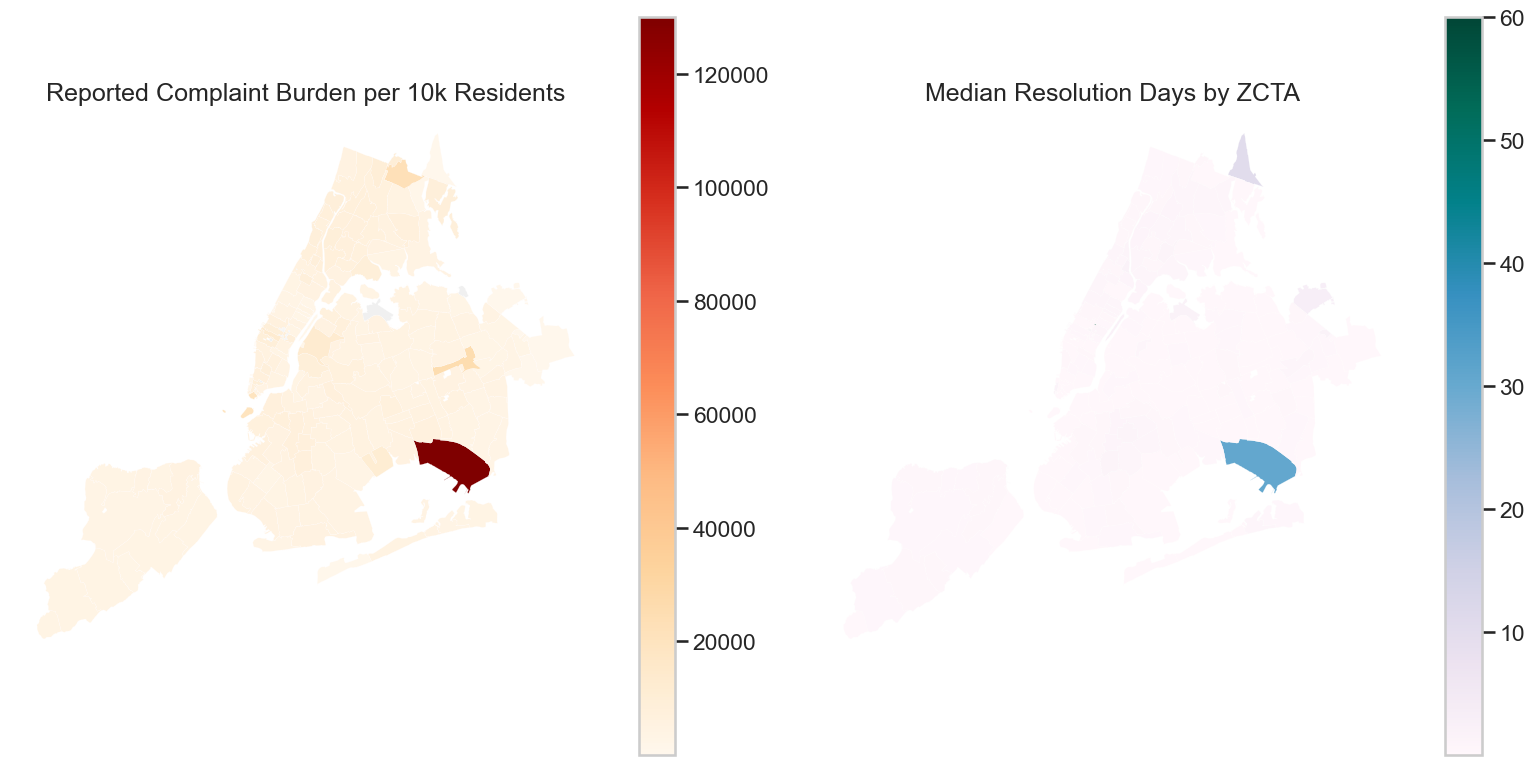

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
zcta_map.plot(column='complaints_per_10k', cmap='OrRd', linewidth=0.15, edgecolor='white', legend=True, ax=axes[0], missing_kwds={'color': '#f0f0f0'})
axes[0].set_title('Reported Complaint Burden per 10k Residents')
axes[0].axis('off')
zcta_map.plot(column='median_resolution_days', cmap='PuBuGn', linewidth=0.15, edgecolor='white', legend=True, ax=axes[1], missing_kwds={'color': '#f0f0f0'})
axes[1].set_title('Median Resolution Days by ZCTA')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Demographic Quintile Comparisons

Quintiles make the fairness story easier to read than a long ZIP ranking. They also reduce the temptation to over-interpret any one neighborhood.

,income_quintile,zctas,median_complaints_per_10k,median_resolution_days,median_unresolved_share
0,Q1 lowest income,51,"7,083.5064",0.5d,3.9%
1,Q2,22,"5,062.9097",0.4d,3.3%
2,Q3,33,"4,896.5463",0.3d,2.9%
3,Q4,43,"4,926.0438",0.2d,4.0%
4,Q5 highest income,61,"3,971.1644",0.3d,4.5%


,poverty_quintile,zctas,median_complaints_per_10k,median_resolution_days,median_unresolved_share
0,Q1 lowest poverty,66,"4,029.7811",0.2d,4.4%
1,Q2,39,"5,193.3028",0.2d,3.1%
2,Q3,33,"5,181.6415",0.4d,3.1%
3,Q4,22,"5,044.7714",0.3d,3.4%
4,Q5 highest poverty,26,"6,993.6731",0.8d,3.6%
5,NaN,24,NaN,0.1d,7.0%


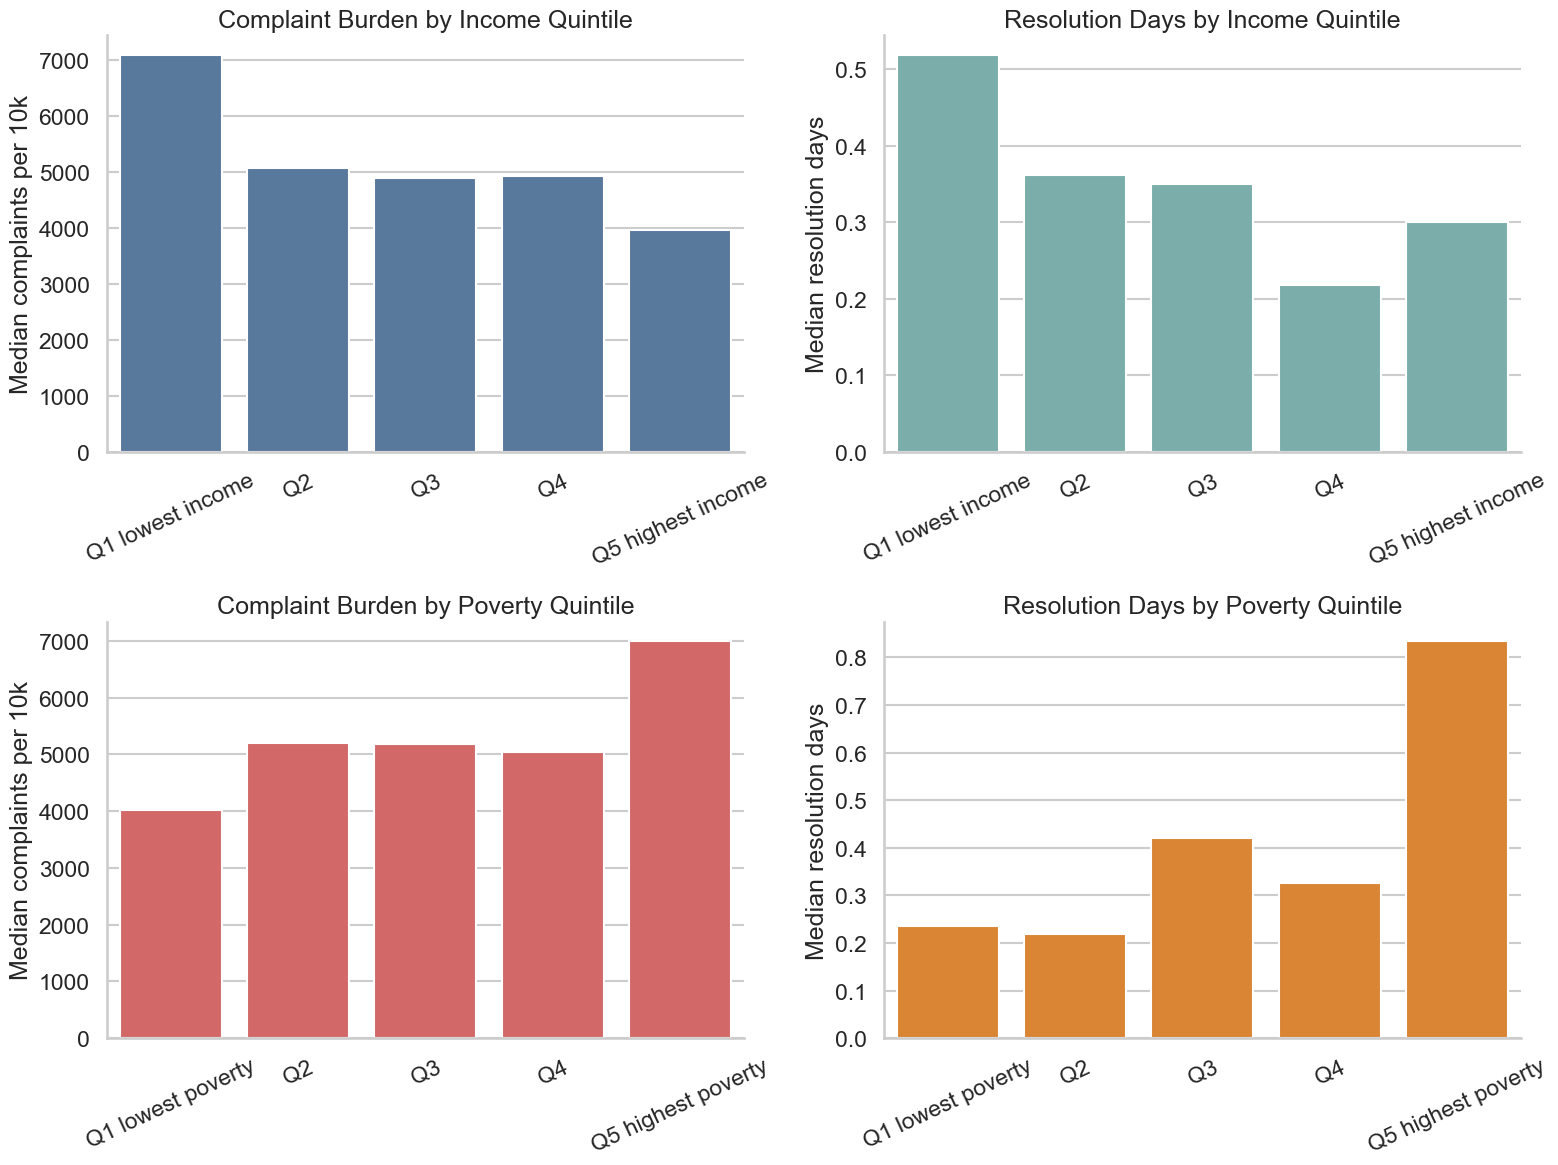

In [6]:
income_quintile_summary = (
    zcta_metrics.groupby('income_quintile', dropna=False)
    .agg(
        zctas=('zcta', 'nunique'),
        median_complaints_per_10k=('complaints_per_10k', 'median'),
        median_resolution_days=('median_resolution_days', 'median'),
        median_unresolved_share=('unresolved_share', 'median'),
    )
    .reset_index()
)
income_quintile_summary['income_quintile'] = pd.Categorical(income_quintile_summary['income_quintile'], QUINTILE_ORDER['income_quintile'], ordered=True)
income_quintile_summary = income_quintile_summary.sort_values('income_quintile')

poverty_quintile_summary = (
    zcta_metrics.groupby('poverty_quintile', dropna=False)
    .agg(
        zctas=('zcta', 'nunique'),
        median_complaints_per_10k=('complaints_per_10k', 'median'),
        median_resolution_days=('median_resolution_days', 'median'),
        median_unresolved_share=('unresolved_share', 'median'),
    )
    .reset_index()
)
poverty_quintile_summary['poverty_quintile'] = pd.Categorical(poverty_quintile_summary['poverty_quintile'], QUINTILE_ORDER['poverty_quintile'], ordered=True)
poverty_quintile_summary = poverty_quintile_summary.sort_values('poverty_quintile')

display(trim_table(income_quintile_summary, percent_cols=['median_unresolved_share'], day_cols=['median_resolution_days']))
display(trim_table(poverty_quintile_summary, percent_cols=['median_unresolved_share'], day_cols=['median_resolution_days']))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.barplot(data=income_quintile_summary, x='income_quintile', y='median_complaints_per_10k', color='#4C78A8', ax=axes[0, 0])
axes[0, 0].set_title('Complaint Burden by Income Quintile')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Median complaints per 10k')
sns.barplot(data=income_quintile_summary, x='income_quintile', y='median_resolution_days', color='#72B7B2', ax=axes[0, 1])
axes[0, 1].set_title('Resolution Days by Income Quintile')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Median resolution days')
sns.barplot(data=poverty_quintile_summary, x='poverty_quintile', y='median_complaints_per_10k', color='#E45756', ax=axes[1, 0])
axes[1, 0].set_title('Complaint Burden by Poverty Quintile')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('Median complaints per 10k')
sns.barplot(data=poverty_quintile_summary, x='poverty_quintile', y='median_resolution_days', color='#F58518', ax=axes[1, 1])
axes[1, 1].set_title('Resolution Days by Poverty Quintile')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Median resolution days')
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

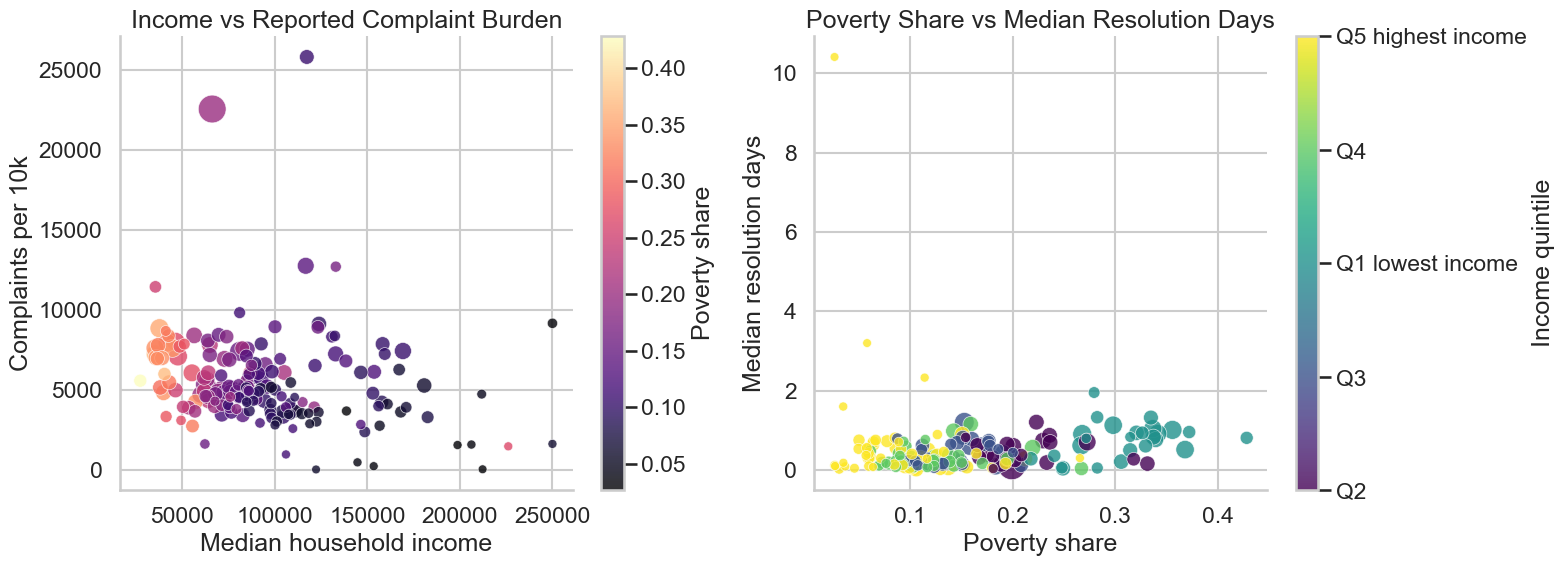

In [7]:
plot_df = zcta_metrics.loc[(zcta_metrics['population'] >= 5000) & zcta_metrics['median_household_income'].notna()].copy()
plot_df['complaints_float'] = pd.to_numeric(plot_df['complaints'], errors='coerce').astype(float)
plot_df['income_float'] = pd.to_numeric(plot_df['median_household_income'], errors='coerce').astype(float)
plot_df['burden_float'] = pd.to_numeric(plot_df['complaints_per_10k'], errors='coerce').astype(float)
plot_df['poverty_float'] = pd.to_numeric(plot_df['poverty_share'], errors='coerce').astype(float)
plot_df['resolution_float'] = pd.to_numeric(plot_df['median_resolution_days'], errors='coerce').astype(float)
size_scale = np.interp(plot_df['complaints_float'], (plot_df['complaints_float'].min(), plot_df['complaints_float'].max()), (40, 400))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
scatter_a = axes[0].scatter(
    plot_df['income_float'],
    plot_df['burden_float'],
    s=size_scale,
    c=plot_df['poverty_float'],
    cmap='magma',
    alpha=0.8,
    edgecolors='white',
    linewidths=0.5,
)
axes[0].set_title('Income vs Reported Complaint Burden')
axes[0].set_xlabel('Median household income')
axes[0].set_ylabel('Complaints per 10k')
fig.colorbar(scatter_a, ax=axes[0], label='Poverty share')

income_codes, income_labels = pd.factorize(plot_df['income_quintile'])
scatter_b = axes[1].scatter(
    plot_df['poverty_float'],
    plot_df['resolution_float'],
    s=size_scale,
    c=income_codes,
    cmap='viridis',
    alpha=0.8,
    edgecolors='white',
    linewidths=0.5,
)
axes[1].set_title('Poverty Share vs Median Resolution Days')
axes[1].set_xlabel('Poverty share')
axes[1].set_ylabel('Median resolution days')
colorbar = fig.colorbar(scatter_b, ax=axes[1])
colorbar.set_ticks(range(len(income_labels)))
colorbar.set_ticklabels(income_labels)
colorbar.set_label('Income quintile')
plt.tight_layout()
plt.show()

## Adjusted Neighborhood Gaps

Raw neighborhood differences are not enough on their own. This view compares each ZCTA against the citywide benchmark for the same complaint type and agency.

,zcta,issue_value,agency,complaints,median_resolution_gap_days,unresolved_share_gap,income_quintile,poverty_quintile
9960,10312,Root/Sewer/Sidewalk Condition,DPR,366,71.9d,11.3%,Q5 highest income,Q1 lowest poverty
7973,11430,For Hire Vehicle Complaint,TLC,629,33.1d,16.4%,Q1 lowest income,Q5 highest poverty
6901,11215,Maintenance or Facility,DPR,696,31.0d,2.7%,Q5 highest income,Q1 lowest poverty
7623,11217,Noise - Helicopter,EDC,959,28.5d,-13.7%,Q5 highest income,Q1 lowest poverty
7777,11236,Consumer Complaint,DCWP,336,26.3d,0.6%,Q3,Q2
7773,11101,Consumer Complaint,DCWP,367,26.3d,3.2%,Q5 highest income,Q2
7774,10036,Consumer Complaint,DCWP,362,25.7d,1.7%,Q4,Q2
8351,11220,Graffiti,DSNY,695,25.0d,3.8%,Q2,Q4
6920,11213,Maintenance or Facility,DPR,329,25.0d,6.4%,Q2,Q4
9962,11234,Root/Sewer/Sidewalk Condition,DPR,274,24.4d,17.9%,Q4,Q1 lowest poverty


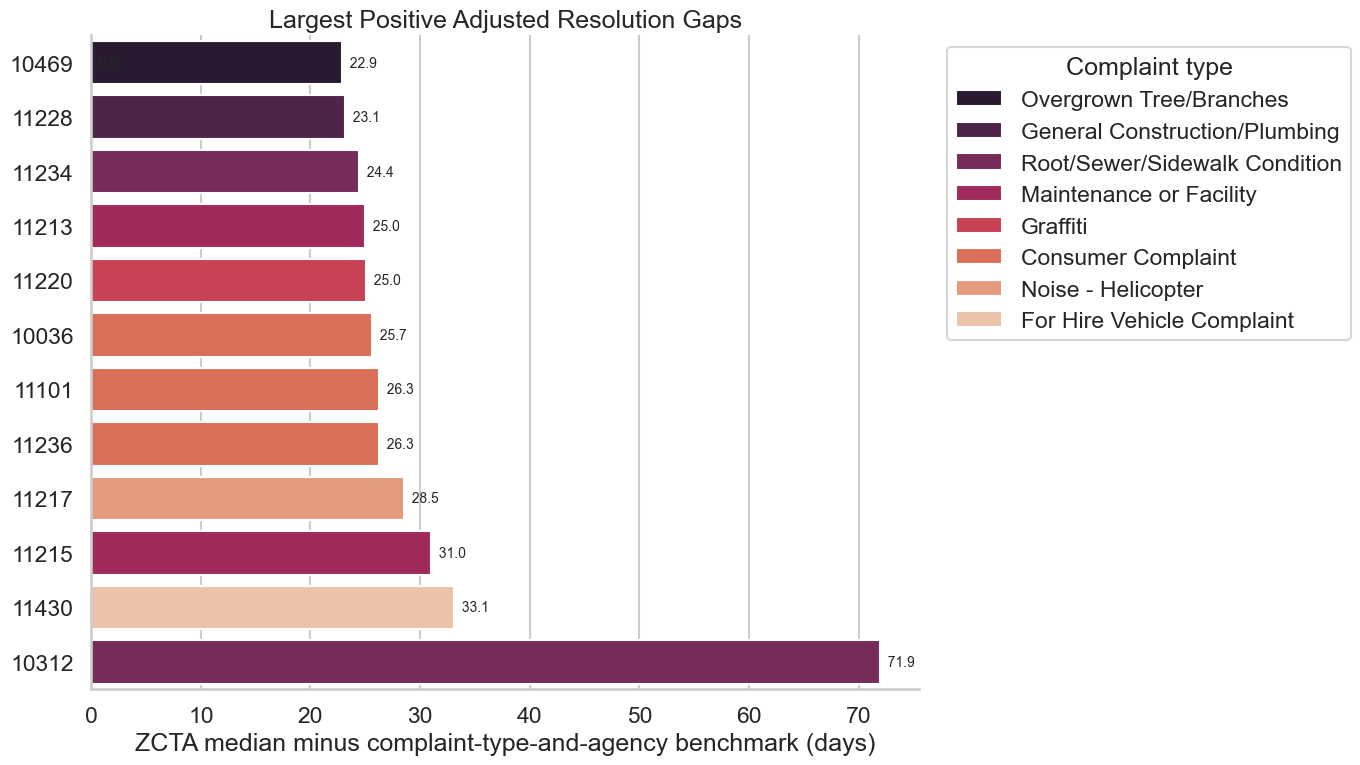

In [8]:
worst_adjusted = (
    zcta_stratified.loc[
        (zcta_stratified['issue_level'] == 'complaint_type')
        & (zcta_stratified['complaints'] >= STRAT_MIN)
        & (zcta_stratified['median_resolution_gap_days'] > 0)
    ]
    .sort_values(['median_resolution_gap_days', 'complaints'], ascending=[False, False])
    .head(12)
)

display(trim_table(worst_adjusted[['zcta', 'issue_value', 'agency', 'complaints', 'median_resolution_gap_days', 'unresolved_share_gap', 'income_quintile', 'poverty_quintile']], percent_cols=['unresolved_share_gap'], day_cols=['median_resolution_gap_days']))

plot_df = worst_adjusted.sort_values('median_resolution_gap_days', ascending=True)
fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(data=plot_df, x='median_resolution_gap_days', y='zcta', hue='issue_value', dodge=False, palette='rocket', ax=ax)
annotate_barh(ax)
ax.set_title('Largest Positive Adjusted Resolution Gaps')
ax.set_xlabel('ZCTA median minus complaint-type-and-agency benchmark (days)')
ax.set_ylabel('')
ax.legend(title='Complaint type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

,poverty_quintile,cells,median_gap_days,median_unresolved_gap
0,Q1 lowest poverty,801,-0.0d,-0.0%
1,Q2,730,0.0d,-0.0%
2,Q3,736,0.0d,-0.0%
3,Q4,563,0.0d,-0.0%
4,Q5 highest poverty,610,0.0d,-0.0%


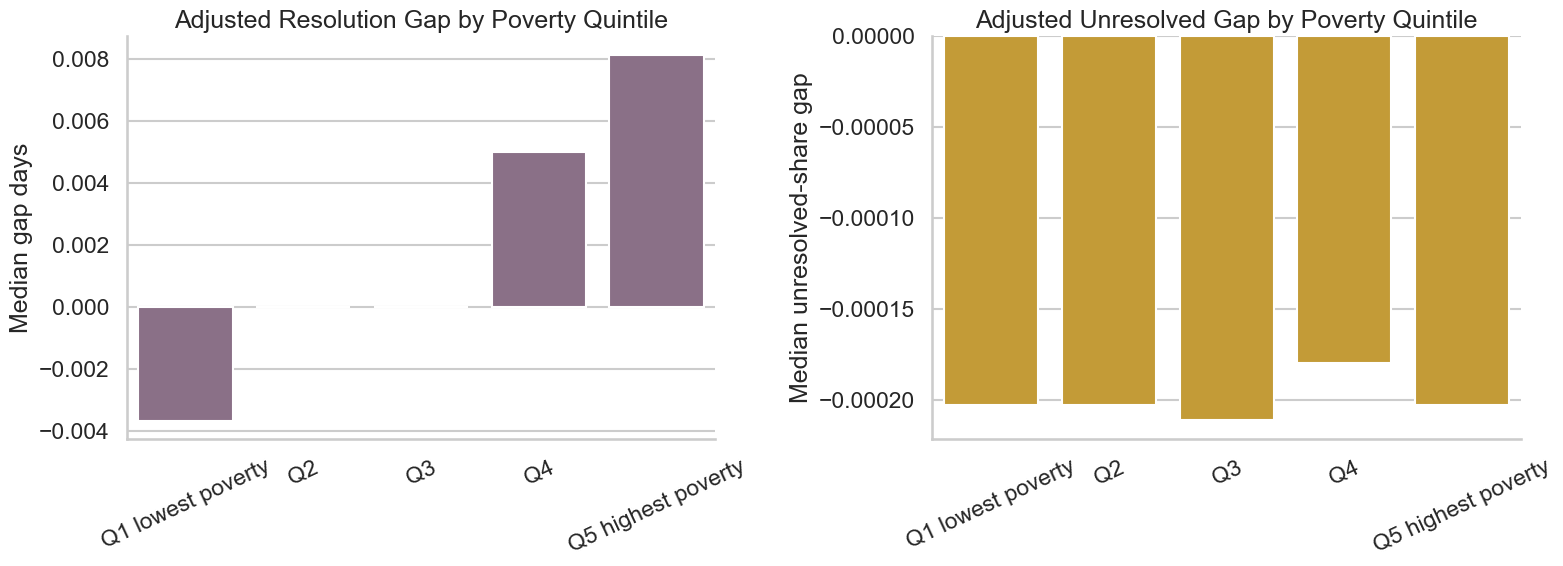

In [9]:
poverty_gap_summary = (
    zcta_stratified.loc[(zcta_stratified['issue_level'] == 'complaint_type') & (zcta_stratified['complaints'] >= STRAT_MIN)]
    .groupby('poverty_quintile', dropna=False)
    .agg(
        cells=('zcta', 'size'),
        median_gap_days=('median_resolution_gap_days', 'median'),
        median_unresolved_gap=('unresolved_share_gap', 'median'),
    )
    .reset_index()
)
poverty_gap_summary['poverty_quintile'] = pd.Categorical(poverty_gap_summary['poverty_quintile'], QUINTILE_ORDER['poverty_quintile'], ordered=True)
poverty_gap_summary = poverty_gap_summary.sort_values('poverty_quintile')

display(trim_table(poverty_gap_summary, percent_cols=['median_unresolved_gap'], day_cols=['median_gap_days']))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=poverty_gap_summary, x='poverty_quintile', y='median_gap_days', color='#8E6C8A', ax=axes[0])
axes[0].set_title('Adjusted Resolution Gap by Poverty Quintile')
axes[0].set_xlabel('')
axes[0].set_ylabel('Median gap days')
sns.barplot(data=poverty_gap_summary, x='poverty_quintile', y='median_unresolved_gap', color='#DAA520', ax=axes[1])
axes[1].set_title('Adjusted Unresolved Gap by Poverty Quintile')
axes[1].set_xlabel('')
axes[1].set_ylabel('Median unresolved-share gap')
for ax in axes:
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

## Monthly Fairness Trends

The monthly view is intentionally simple: compare complete-month unresolved shares for the lowest- and highest-poverty ZCTA groups.

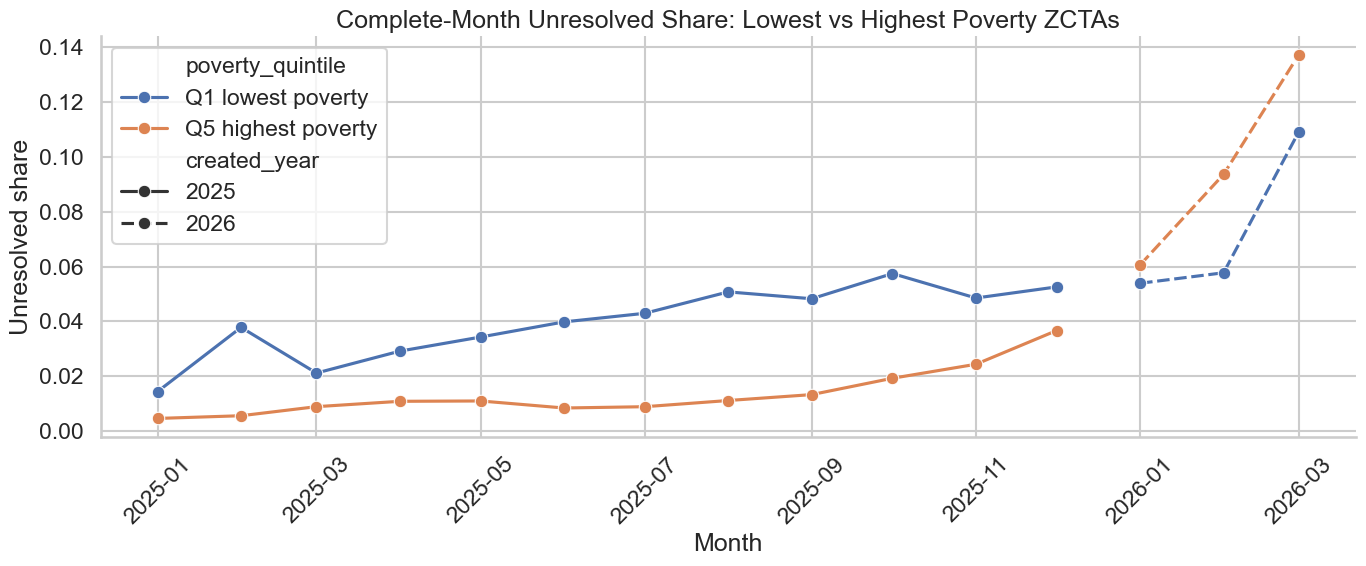

In [10]:
poverty_monthly = (
    monthly_complete.groupby(['created_month_start', 'created_year', 'poverty_quintile'], dropna=False)
    .agg(
        complaints=('complaints', 'sum'),
        unresolved_complaints=('unresolved_complaints', 'sum'),
    )
    .reset_index()
)
poverty_monthly['unresolved_share'] = poverty_monthly['unresolved_complaints'] / poverty_monthly['complaints']
poverty_monthly = poverty_monthly.loc[poverty_monthly['poverty_quintile'].isin(['Q1 lowest poverty', 'Q5 highest poverty'])]

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=poverty_monthly, x='created_month_start', y='unresolved_share', hue='poverty_quintile', style='created_year', marker='o', ax=ax)
ax.set_title('Complete-Month Unresolved Share: Lowest vs Highest Poverty ZCTAs')
ax.set_xlabel('Month')
ax.set_ylabel('Unresolved share')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Lightweight Adjusted Models

These models are secondary checks. They use demographic quintiles plus complaint type, agency, borough, year, and season controls.

Read them directionally, not as causal estimates.

In [11]:
model_display = model_results.copy()
model_display['feature_clean'] = (
    model_display['feature']
    .str.replace('categorical__', '', regex=False)
    .str.replace('_', ' ', regex=False)
)

duration_top = (
    model_display.loc[model_display['model_name'].eq('log_resolution_days')]
    .assign(abs_coef=lambda frame: frame['coefficient'].abs())
    .sort_values('abs_coef', ascending=False)
    .head(8)
)
backlog_top = (
    model_display.loc[model_display['model_name'].eq('unresolved_log_odds')]
    .assign(abs_coef=lambda frame: frame['coefficient'].abs())
    .sort_values('abs_coef', ascending=False)
    .head(8)
)

display(duration_top[['feature_clean', 'coefficient', 'metric', 'metric_value', 'sample_rows']])
display(backlog_top[['feature_clean', 'coefficient', 'metric', 'metric_value', 'sample_rows']])

,feature_clean,coefficient,metric,metric_value,sample_rows
7,income quintile Q5 highest income,-0.0323,r2,0.6725,250000
19,renter quintile Q5 highest renter,-0.0257,r2,0.6725,250000
0,education quintile Q2,0.0240,r2,0.6725,250000
9,nonwhite quintile Q3,-0.0196,r2,0.6725,250000
3,education quintile Q5 highest education,0.0176,r2,0.6725,250000
13,poverty quintile Q3,-0.0171,r2,0.6725,250000
4,income quintile Q2,0.0147,r2,0.6725,250000
17,renter quintile Q3,-0.0133,r2,0.6725,250000


,feature_clean,coefficient,metric,metric_value,sample_rows
23,education quintile Q5 highest education,0.3248,roc_auc,0.9416,250000
31,nonwhite quintile Q5 highest nonwhite,0.2864,roc_auc,0.9416,250000
35,poverty quintile Q5 highest poverty,0.2615,roc_auc,0.9416,250000
29,nonwhite quintile Q3,0.2104,roc_auc,0.9416,250000
30,nonwhite quintile Q4,0.1881,roc_auc,0.9416,250000
27,income quintile Q5 highest income,0.1747,roc_auc,0.9416,250000
22,education quintile Q4,0.1590,roc_auc,0.9416,250000
26,income quintile Q4,0.1545,roc_auc,0.9416,250000


## Community Board Sensitivity Check

ZIPs are the main demographic unit, but community boards are still useful as a robustness check because they have stronger operational coverage.

In [12]:
slow_boards = (
    community_board_sensitivity.loc[community_board_sensitivity['complaints'] >= BOARD_MIN]
    .sort_values('median_resolution_days', ascending=False)
    .head(12)
)

display(trim_table(slow_boards[['community_board', 'complaints', 'median_resolution_days', 'p90_resolution_days', 'unresolved_share', 'status_backlog_share', 'top_agency', 'top_complaint_type']], percent_cols=['unresolved_share', 'status_backlog_share'], day_cols=['median_resolution_days', 'p90_resolution_days']))

,community_board,complaints,median_resolution_days,p90_resolution_days,unresolved_share,status_backlog_share,top_agency,top_complaint_type
8,06 BRONX,64916,1.2d,19.9d,3.3%,3.5%,HPD,HEAT/HOT WATER
11,02 BRONX,36526,1.1d,23.2d,4.6%,4.8%,HPD,HEAT/HOT WATER
22,17 BROOKLYN,84468,1.1d,18.0d,3.4%,3.8%,HPD,HEAT/HOT WATER
1,04 BRONX,119846,1.0d,18.3d,3.7%,3.8%,HPD,HEAT/HOT WATER
38,10 MANHATTAN,108461,1.0d,20.5d,3.7%,3.9%,HPD,HEAT/HOT WATER
3,05 BRONX,101399,1.0d,18.9d,3.7%,3.9%,HPD,HEAT/HOT WATER
30,09 BROOKLYN,66351,0.9d,17.1d,3.3%,3.6%,HPD,HEAT/HOT WATER
20,03 BROOKLYN,90608,0.9d,17.3d,4.5%,4.9%,NYPD,Noise - Residential
2,07 BRONX,106795,0.9d,16.7d,3.6%,3.7%,HPD,HEAT/HOT WATER
24,08 BROOKLYN,75614,0.9d,18.9d,7.1%,7.5%,NYPD,Illegal Parking


## Findings

The value of Phase 7 is not a single fairness verdict. It is a careful read on where disparity signals appear, where they weaken after adjustment, and where caution still matters.

In [13]:
top_burden = high_burden.iloc[0]
top_slow = slow_zctas.iloc[0]
top_gap = worst_adjusted.iloc[0]
highest_poverty = poverty_quintile_summary.loc[poverty_quintile_summary['poverty_quintile'].eq('Q5 highest poverty')].iloc[0]
lowest_poverty = poverty_quintile_summary.loc[poverty_quintile_summary['poverty_quintile'].eq('Q1 lowest poverty')].iloc[0]

so_what = pd.DataFrame(
    [
        {
            'question': 'Where is reported complaint burden highest?',
            'answer': f"ZCTA {top_burden['zcta']} has the highest complaint burden among neighborhoods with at least 5,000 residents.",
            'evidence': f"{top_burden['complaints_per_10k']:.1f} complaints per 10k residents.",
        },
        {
            'question': 'Where does neighborhood service look slowest?',
            'answer': f"ZCTA {top_slow['zcta']} has the slowest median resolution time among sizable neighborhoods in this Phase 7 cut.",
            'evidence': f"Median {top_slow['median_resolution_days']:.2f} days with poverty share {top_slow['poverty_share']:.1%}.",
        },
        {
            'question': 'Does a gap remain after matching issue and agency?',
            'answer': f"Yes. ZCTA {top_gap['zcta']} on {top_gap['issue_value']} handled by {top_gap['agency']} still sits well above its matched benchmark.",
            'evidence': f"Adjusted median gap {top_gap['median_resolution_gap_days']:.1f} days across {int(top_gap['complaints']):,} complaints.",
        },
        {
            'question': 'What do the quintiles suggest?',
            'answer': 'Higher-poverty neighborhoods show higher reported complaint burden and slower median resolution in the raw ZCTA summaries.',
            'evidence': f"Median burden is {highest_poverty['median_complaints_per_10k']:.0f} per 10k in the highest-poverty quintile versus {lowest_poverty['median_complaints_per_10k']:.0f} in the lowest-poverty quintile; median resolution is {highest_poverty['median_resolution_days']:.2f} vs {lowest_poverty['median_resolution_days']:.2f} days.",
        },
        {
            'question': 'How should this be interpreted?',
            'answer': 'As evidence of area-level disparities in reported service outcomes, not proof of intent.',
            'evidence': 'Complaint reporting, neighborhood context, and unobserved exposure differences can all contribute to these patterns.',
        },
    ]
)
display(so_what)

,question,answer,evidence
0,Where is reported complaint burden highest?,ZCTA 11366 has the highest complaint burden am...,25831.7 complaints per 10k residents.
1,Where does neighborhood service look slowest?,ZCTA 10037 has the slowest median resolution t...,Median 1.96 days with poverty share 27.9%.
2,Does a gap remain after matching issue and age...,Yes. ZCTA 10312 on Root/Sewer/Sidewalk Conditi...,Adjusted median gap 71.9 days across 366 compl...
3,What do the quintiles suggest?,Higher-poverty neighborhoods show higher repor...,Median burden is 6994 per 10k in the highest-p...
4,How should this be interpreted?,As evidence of area-level disparities in repor...,"Complaint reporting, neighborhood context, and..."
